# LLM-as-a-Judge in Finance — Exploratory Analysis

Exploration of judge evaluation results across two regulatory corpora (EBA, ESMA) and two model tiers:
- **Small models** (local): `judge_results_eba.json`, `judge_results_esma.json`
- **Big models** (API): `judge_results_eba_qa_api.json`, `judge_results_esma_qa_api.json`

Each record contains a regulatory Q&A pair scored on **accuracy**, **completeness**, **clarity**, and **overall** (1–5 scale).

In [11]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

BASE = Path("../output")

def load(path):
    with open(BASE / path) as f:
        return json.load(f)

raw = {
    "EBA / small":  load("judge_results_eba.json"),
    "ESMA / small": load("judge_results_esma.json"),
    "EBA / big":    load("judge_results_eba_qa_api.json"),
    "ESMA / big":   load("judge_results_esma_qa_api.json"),
}

DIMS = ["accuracy", "completeness", "clarity", "overall"]

# Explicit metadata — avoids parsing the name string in every cell
DATASET_META = {
    "EBA / small":  {"corpus": "EBA",  "tier": "small"},
    "ESMA / small": {"corpus": "ESMA", "tier": "small"},
    "EBA / big":    {"corpus": "EBA",  "tier": "big"},
    "ESMA / big":   {"corpus": "ESMA", "tier": "big"},
}

def to_df(records):
    rows = []
    for r in records:
        row = {k: r[k] for k in ("id", "question", "ground_truth", "candidate_answer")}
        for d in DIMS:
            val = r["scores"].get(d)
            row[d] = float(val) if val is not None else np.nan
        row["reasoning"] = r["scores"].get("reasoning", "")
        for k, v in r.get("meta", {}).items():
            row[k] = v
        rows.append(row)
    return pd.DataFrame(rows)

dfs = {name: to_df(recs) for name, recs in raw.items()}

print("Datasets loaded:")
for name, df in dfs.items():
    n_valid = df["overall"].notna().sum()
    print(f"  {name:20s}  {len(df):>5} records  ({n_valid} with valid overall score)")

Datasets loaded:
  EBA / small            2669 records  (2666 with valid overall score)
  ESMA / small            383 records  (383 with valid overall score)
  EBA / big              2635 records  (2099 with valid overall score)
  ESMA / big              383 records  (289 with valid overall score)


## 1 · Dataset Overview

In [12]:
# Model info from metadata
print("=== Model information ===")
for name, df in dfs.items():
    answerer = df["answerer_model"].iloc[0] if "answerer_model" in df.columns else "local (small)"
    judge    = df["judge_model"].iloc[0]    if "judge_model"    in df.columns else "local (small)"
    print(f"  {name:20s}  answerer: {answerer}  |  judge: {judge}")

print()

# Summary table
summary = pd.DataFrame({
    "Records":       {n: len(df) for n, df in dfs.items()},
    "Valid scores":  {n: int(df["overall"].notna().sum()) for n, df in dfs.items()},
    "Missing (%)":   {n: f"{df['overall'].isna().mean()*100:.1f}" for n, df in dfs.items()},
    "Mean overall":  {n: f"{df['overall'].mean():.2f}" for n, df in dfs.items()},
    "Std overall":   {n: f"{df['overall'].std():.2f}" for n, df in dfs.items()},
})
summary

=== Model information ===
  EBA / small           answerer: local (small)  |  judge: local (small)
  ESMA / small          answerer: local (small)  |  judge: local (small)
  EBA / big             answerer: swiss-ai/Apertus-70B-Instruct-2509  |  judge: meta-llama/Llama-3.3-70B-Instruct
  ESMA / big            answerer: swiss-ai/Apertus-70B-Instruct-2509  |  judge: meta-llama/Llama-3.3-70B-Instruct



,Records,Valid scores,Missing (%),Mean overall,Std overall
EBA / small,2669,2666,0.1,1.78,1.35
ESMA / small,383,383,0.0,1.81,1.18
EBA / big,2635,2099,20.3,3.10,1.14
ESMA / big,383,289,24.5,2.73,1.14


## 2 · Score Distributions

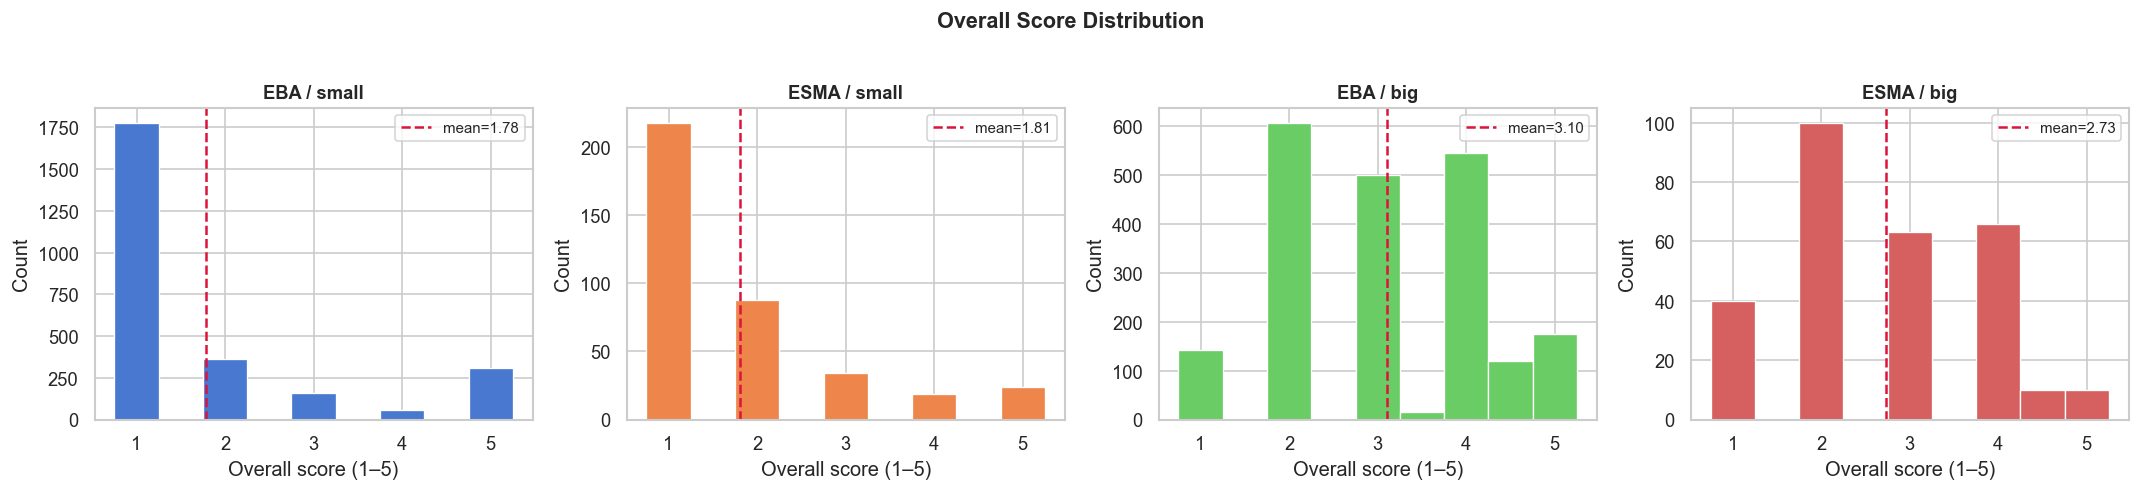

In [13]:
# Overall score distribution per dataset
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

colors = sns.color_palette("muted", 4)

for ax, (name, df), color in zip(axes, dfs.items(), colors):
    data = df["overall"].dropna()
    # bin into 1-5 with 0.5-width buckets so float scores land correctly
    bins = np.arange(0.75, 5.51, 0.5)
    ax.hist(data, bins=bins, color=color, edgecolor="white", linewidth=0.8)
    ax.axvline(data.mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"mean={data.mean():.2f}")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Overall score (1–5)")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend(fontsize=9)

plt.suptitle("Overall Score Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

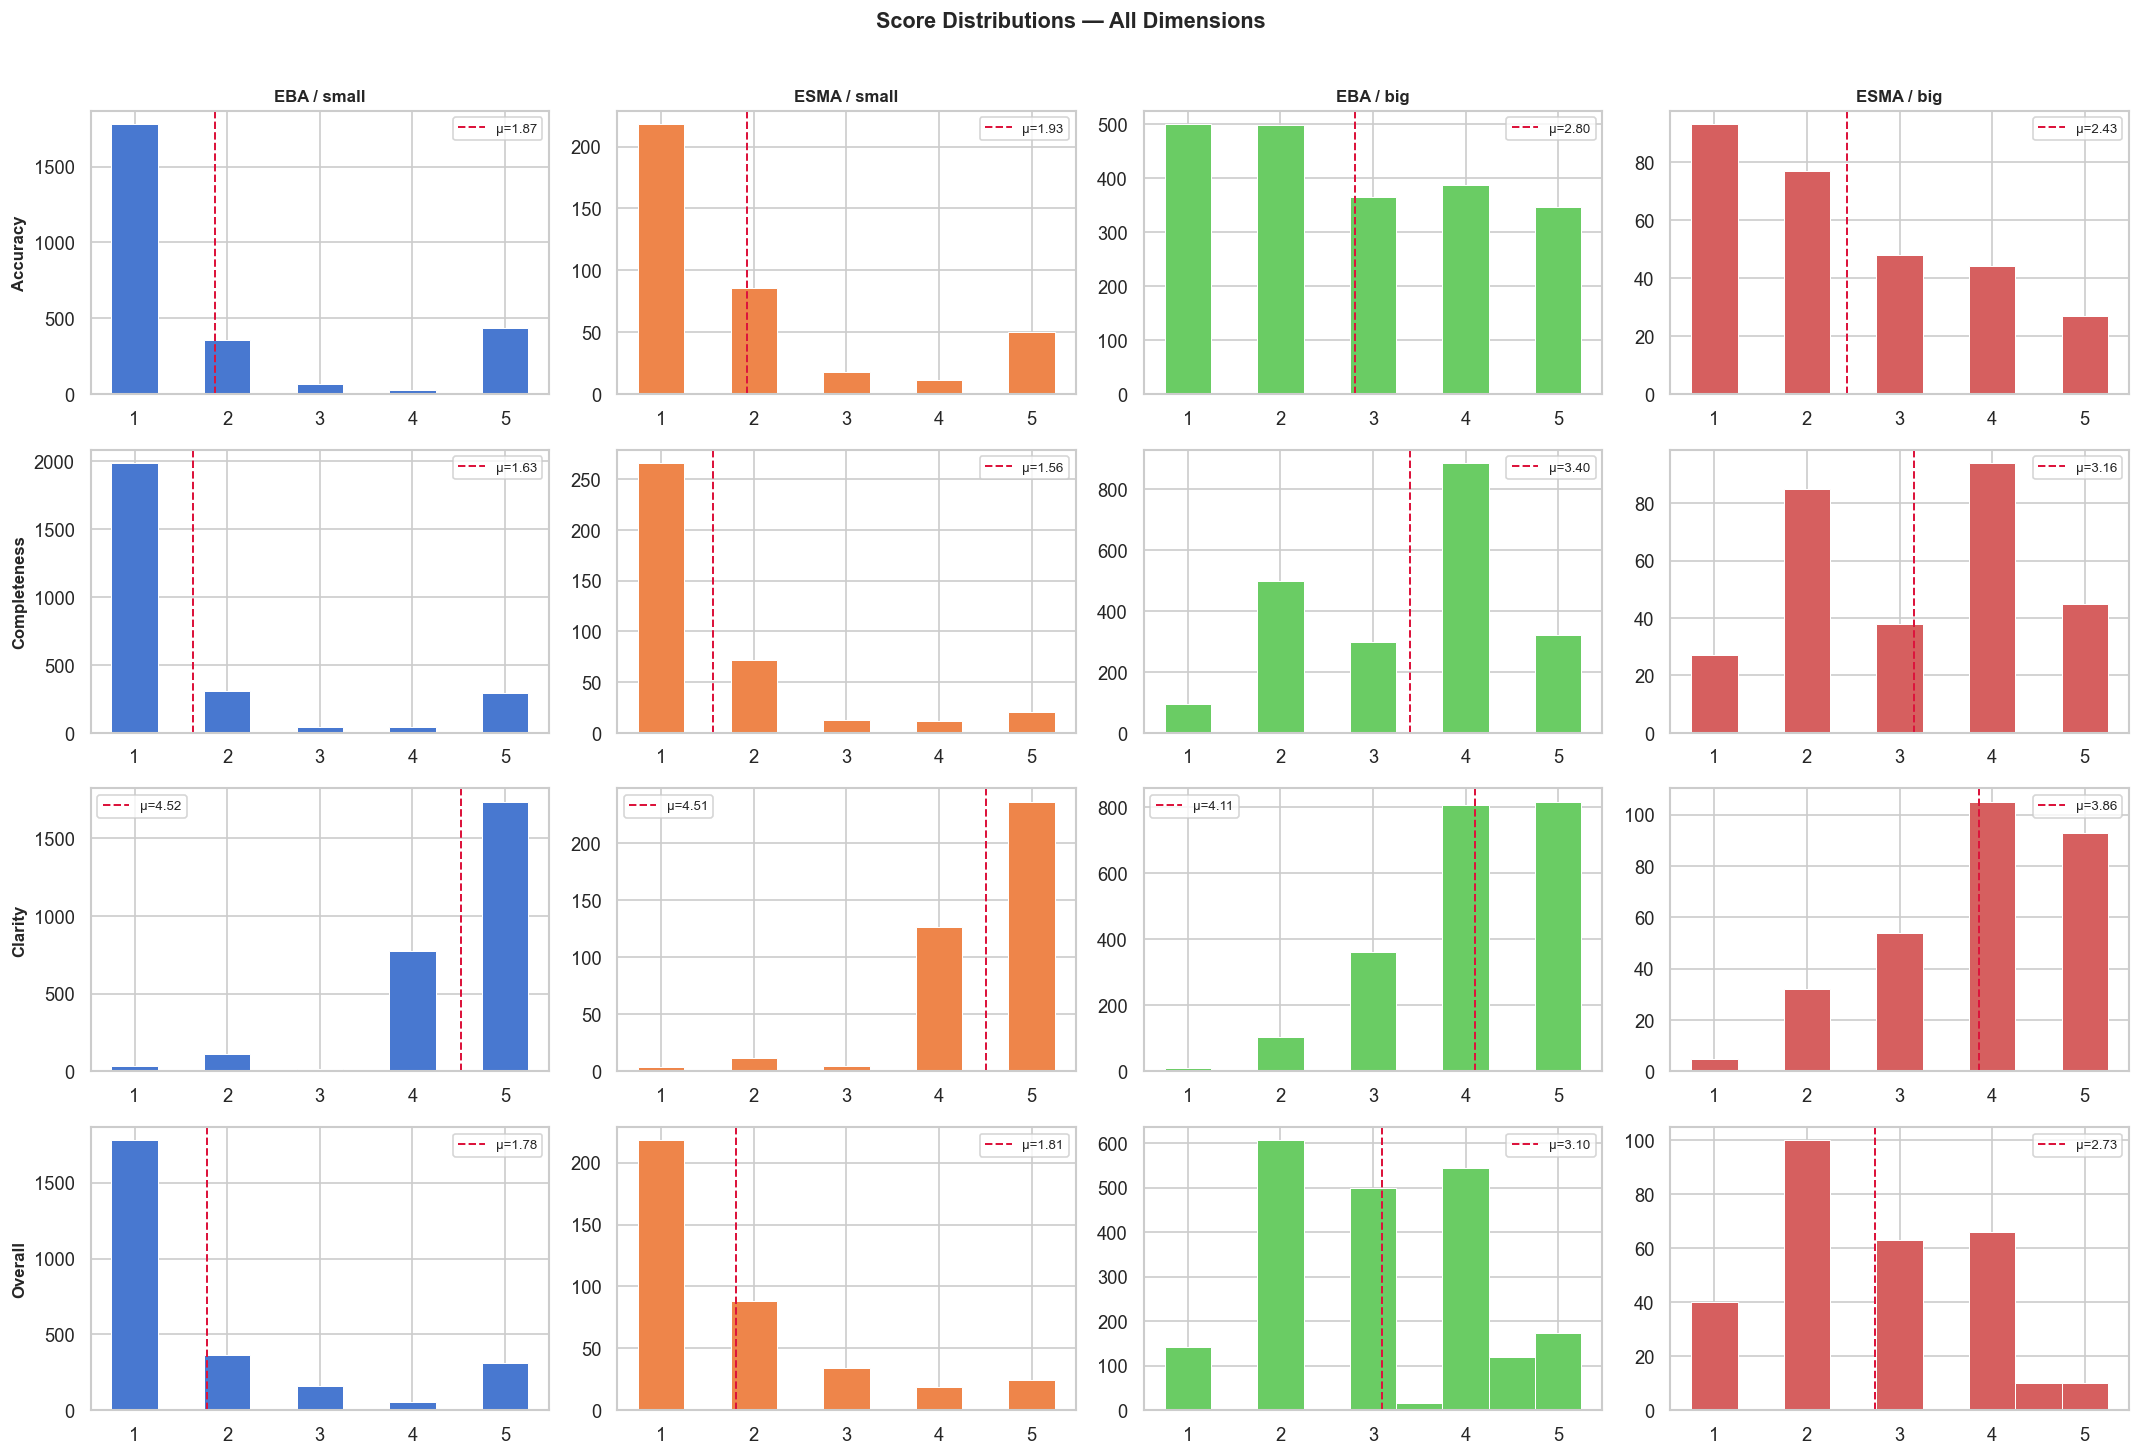

In [14]:
# All four score dimensions — one row per dimension, one column per dataset
fig, axes = plt.subplots(len(DIMS), len(dfs), figsize=(18, 12), sharex="row", sharey=False)
colors = sns.color_palette("muted", 4)

for row, dim in enumerate(DIMS):
    for col, (name, df) in enumerate(dfs.items()):
        ax = axes[row][col]
        data = df[dim].dropna()
        bins = np.arange(0.75, 5.51, 0.5)
        ax.hist(data, bins=bins, color=colors[col], edgecolor="white", linewidth=0.6)
        ax.axvline(data.mean(), color="crimson", linestyle="--", linewidth=1.2,
                   label=f"μ={data.mean():.2f}")
        ax.legend(fontsize=8)
        ax.set_xticks([1, 2, 3, 4, 5])
        if row == 0:
            ax.set_title(name, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(dim.capitalize(), fontsize=10, fontweight="bold")

plt.suptitle("Score Distributions — All Dimensions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3 · Small vs Big Models

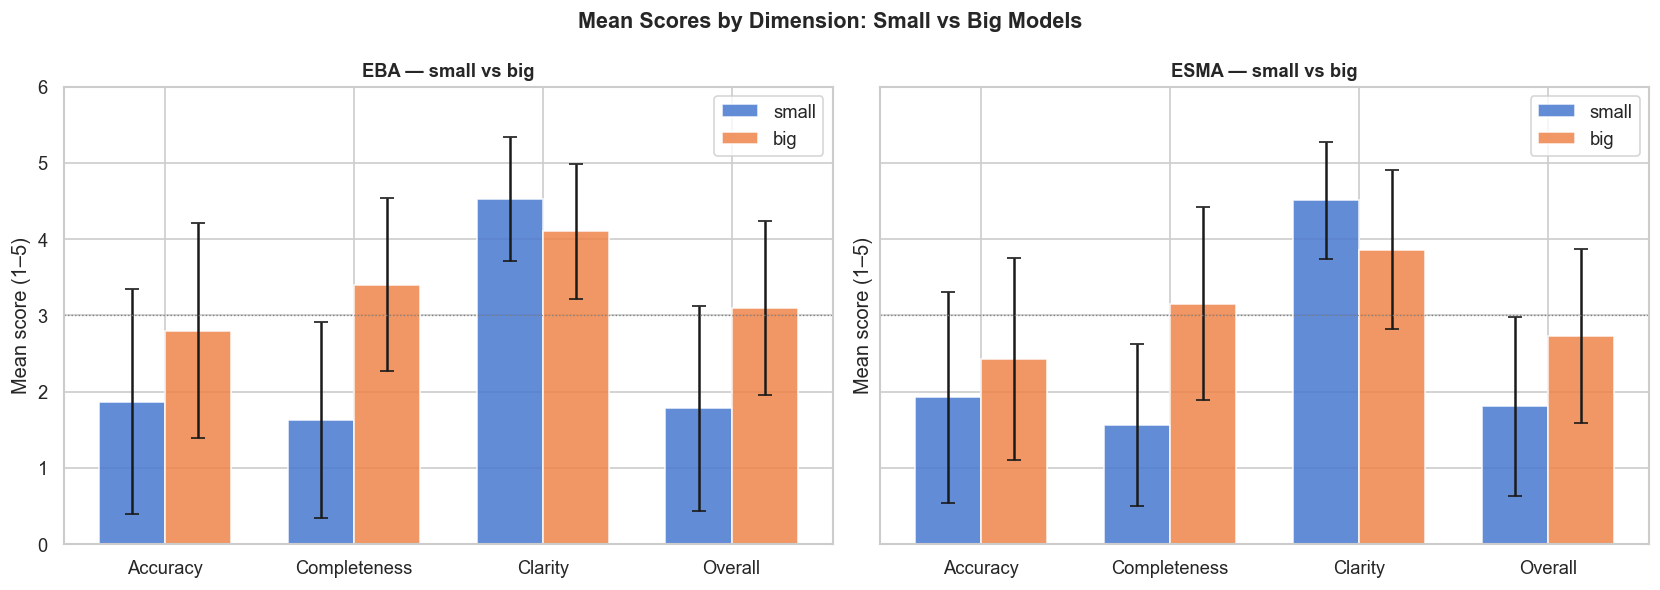

tier                  big  small
corpus dimension                
EBA    accuracy      2.80   1.87
       clarity       4.11   4.52
       completeness  3.40   1.63
       overall       3.10   1.78
ESMA   accuracy      2.43   1.93
       clarity       3.86   4.51
       completeness  3.16   1.56
       overall       2.73   1.81

In [15]:
# Mean ± std for each dimension, small vs big, per corpus
records = []
for name, df in dfs.items():
    corpus = DATASET_META[name]["corpus"]
    tier   = DATASET_META[name]["tier"]
    for dim in DIMS:
        records.append({
            "dataset": name, "corpus": corpus, "tier": tier,
            "dimension": dim,
            "mean": df[dim].mean(),
            "std":  df[dim].std(),
            "n":    df[dim].notna().sum(),
        })

stats = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, corpus in zip(axes, ["EBA", "ESMA"]):
    sub = stats[stats["corpus"] == corpus]
    x = np.arange(len(DIMS))
    width = 0.35
    for tier, offset in [("small", -width/2), ("big", width/2)]:
        t = sub[sub["tier"] == tier].set_index("dimension").reindex(DIMS)
        ax.bar(x + offset, t["mean"], width, yerr=t["std"],
               label=tier, capsize=4, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() for d in DIMS])
    ax.set_ylim(0, 6)
    ax.set_ylabel("Mean score (1–5)")
    ax.set_title(f"{corpus} — small vs big", fontsize=11, fontweight="bold")
    ax.legend()
    ax.axhline(3, color="grey", linestyle=":", linewidth=0.8)

plt.suptitle("Mean Scores by Dimension: Small vs Big Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Numeric comparison table
pivot = stats.pivot_table(index=["corpus", "dimension"], columns="tier", values="mean").round(2)
pivot

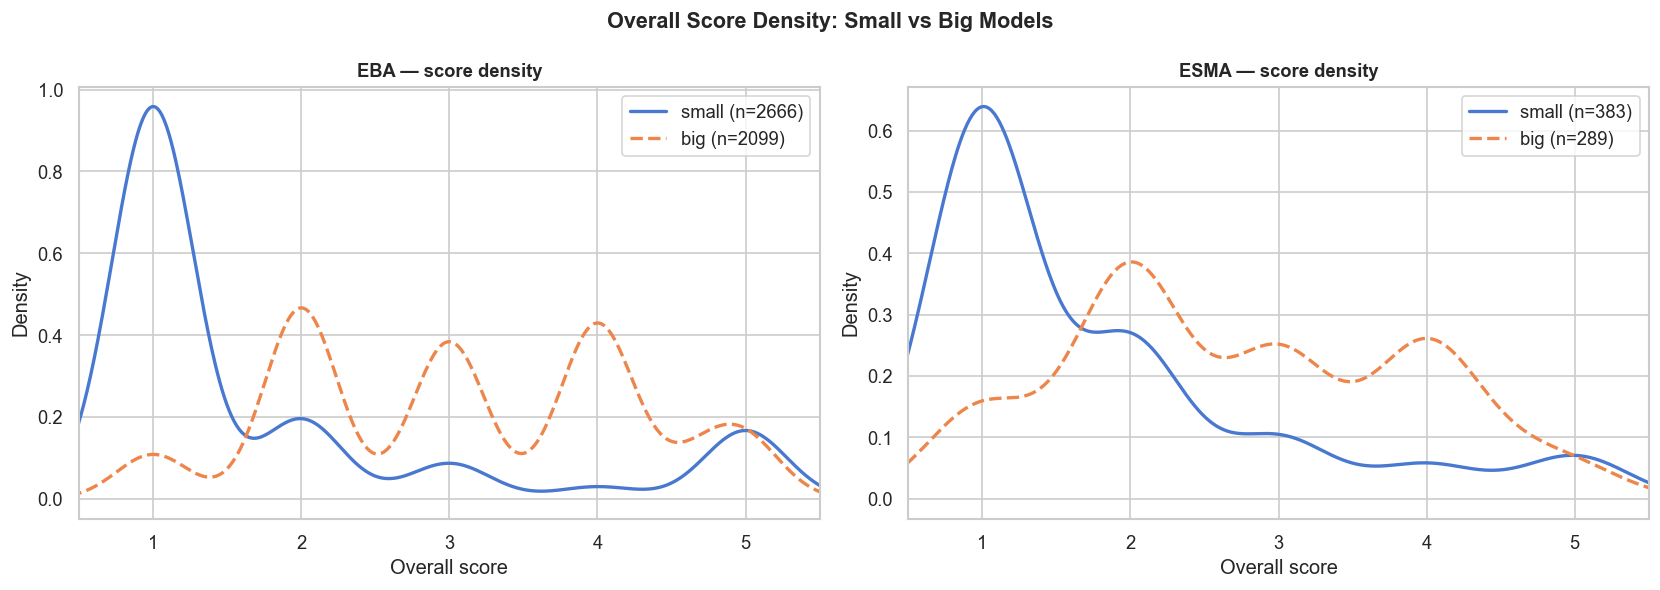

In [16]:
# KDE overlay: overall score distribution small vs big, per corpus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corpus in zip(axes, ["EBA", "ESMA"]):
    for tier, ls in [("small", "-"), ("big", "--")]:
        key = f"{corpus} / {tier}"
        data = dfs[key]["overall"].dropna()
        data.plot.kde(ax=ax, label=f"{tier} (n={len(data)})", linestyle=ls, linewidth=2)
    ax.set_xlim(0.5, 5.5)
    ax.set_xlabel("Overall score")
    ax.set_ylabel("Density")
    ax.set_title(f"{corpus} — score density", fontsize=11, fontweight="bold")
    ax.legend()

plt.suptitle("Overall Score Density: Small vs Big Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 · EBA vs ESMA Comparison

/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_79826/3640583159.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data.values(), labels=plot_data.keys(), patch_artist=True,
/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_79826/3640583159.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data.values(), labels=plot_data.keys(), patch_artist=True,


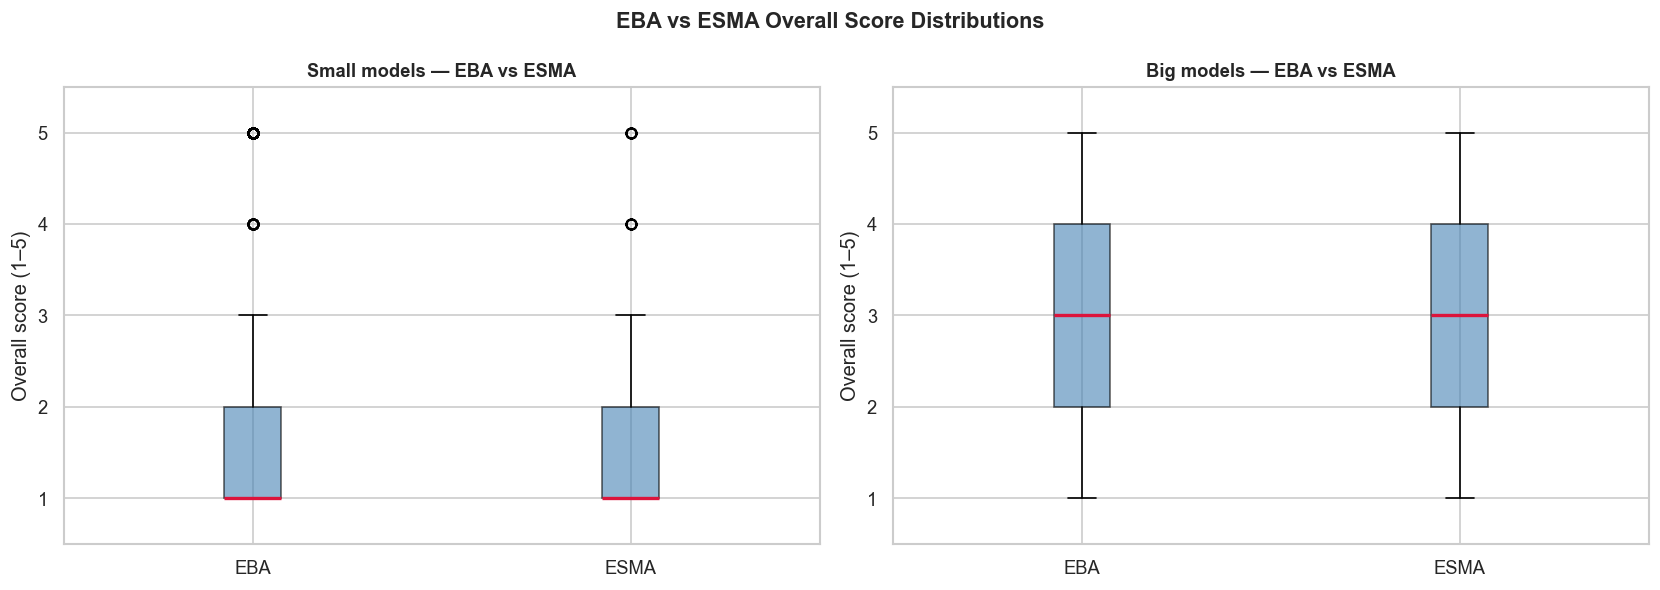

,,median,Q1,Q3,mean
corpus,tier,,,,
EBA,small,1.0,1.0,2.0,1.78
ESMA,small,1.0,1.0,2.0,1.81
EBA,big,3.0,2.0,4.0,3.10
ESMA,big,3.0,2.0,4.0,2.73


In [17]:
# Box plots: EBA vs ESMA for each tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tier in zip(axes, ["small", "big"]):
    plot_data = {}
    for corpus in ["EBA", "ESMA"]:
        key = f"{corpus} / {tier}"
        plot_data[corpus] = dfs[key]["overall"].dropna().values

    ax.boxplot(plot_data.values(), labels=plot_data.keys(), patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="crimson", linewidth=2))
    ax.set_ylabel("Overall score (1–5)")
    ax.set_title(f"{tier.capitalize()} models — EBA vs ESMA", fontsize=11, fontweight="bold")
    ax.set_ylim(0.5, 5.5)

plt.suptitle("EBA vs ESMA Overall Score Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Median and IQR table
eba_esma = []
for tier in ["small", "big"]:
    for corpus in ["EBA", "ESMA"]:
        key = f"{corpus} / {tier}"
        d = dfs[key]["overall"].dropna()
        eba_esma.append({
            "corpus": corpus, "tier": tier,
            "median": d.median(), "Q1": d.quantile(0.25), "Q3": d.quantile(0.75),
            "mean": d.mean().round(2),
        })

pd.DataFrame(eba_esma).set_index(["corpus", "tier"]).round(2)

## 5 · Breakdown by Legal Act and Topic

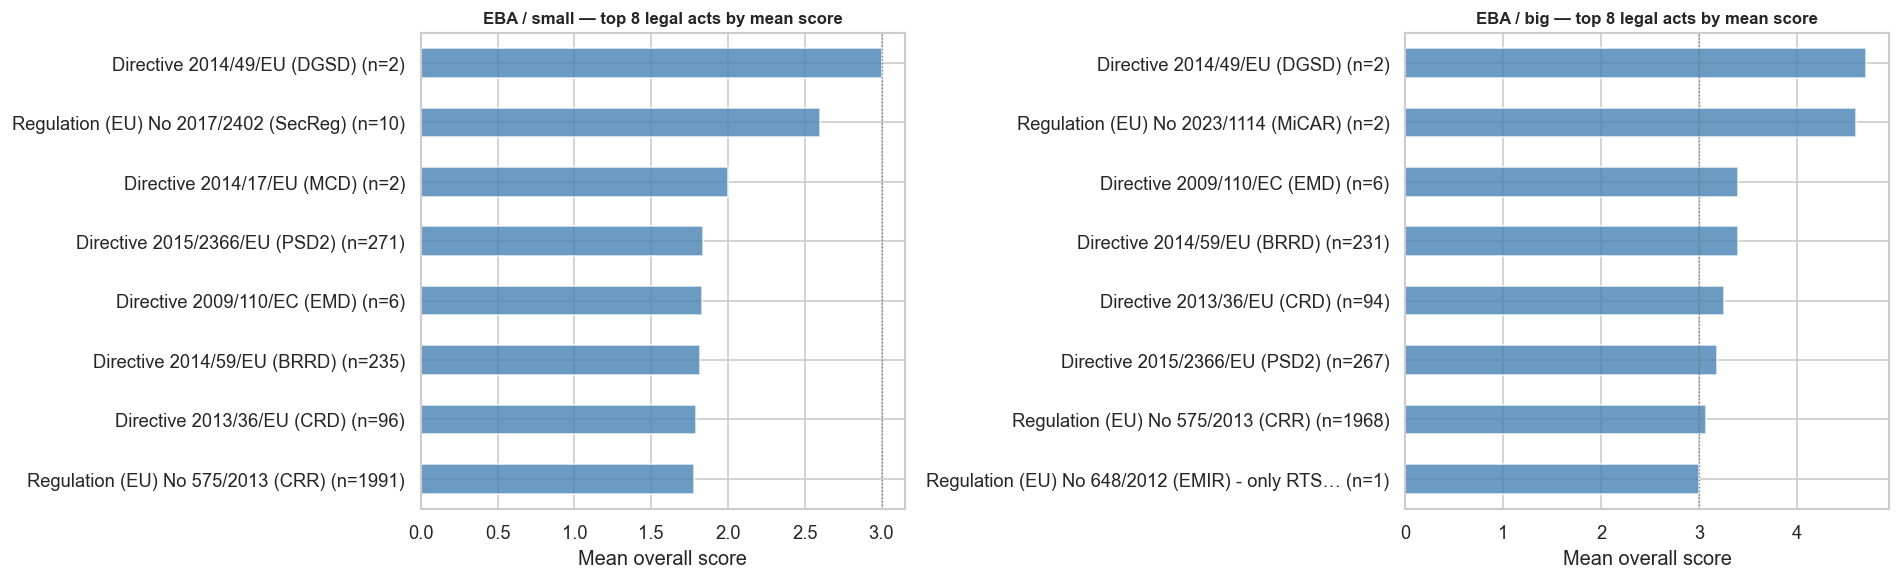

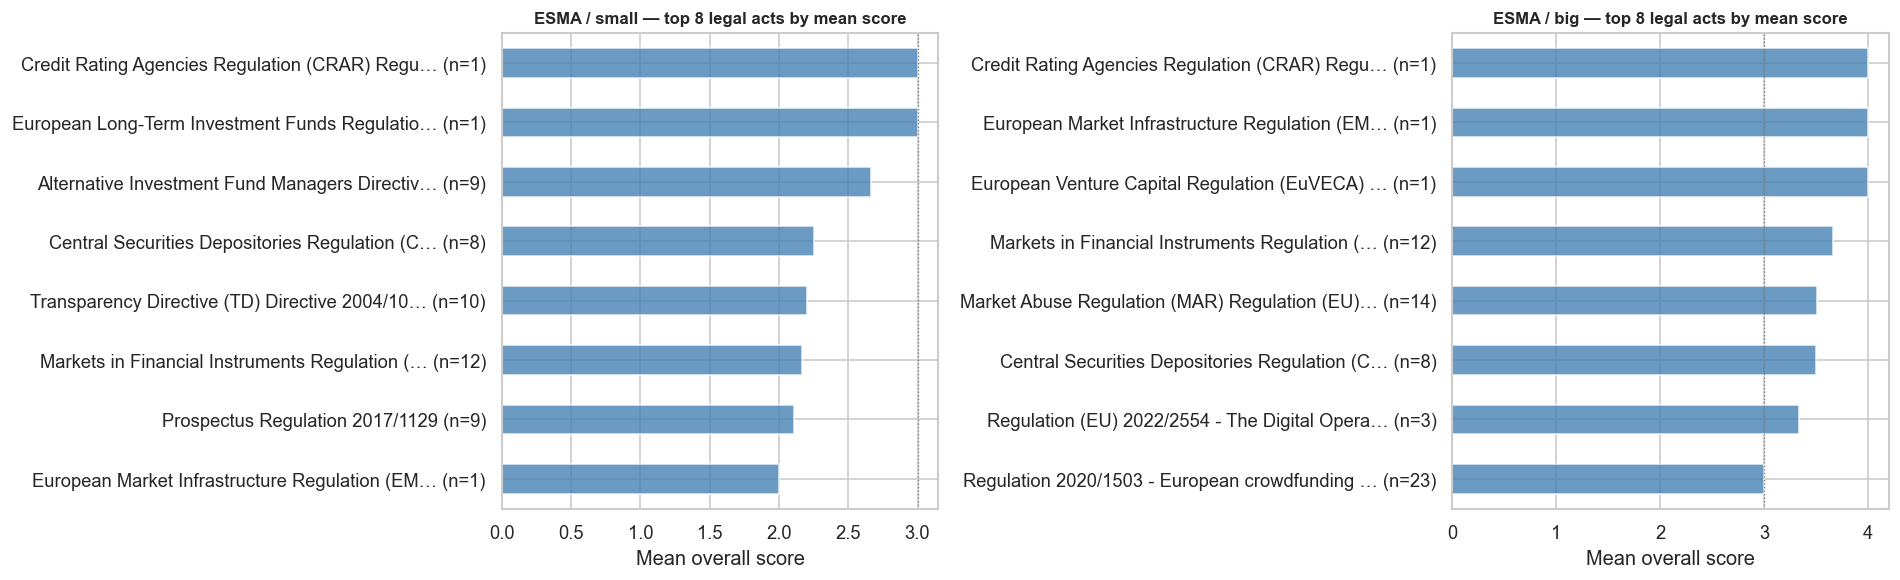

In [18]:
def shorten(s, n=45):
    return s[:n] + "…" if isinstance(s, str) and len(s) > n else s

def top_legal_act_plot(df_small, df_big, corpus, top_n=8):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, (df, tier) in zip(axes, [(df_small, "small"), (df_big, "big")]):
        top = (df.groupby("legal_act")["overall"]
                 .mean()
                 .dropna()
                 .sort_values(ascending=False)
                 .head(top_n))
        counts = df["legal_act"].value_counts().reindex(top.index)
        labels = [f"{shorten(la)} (n={counts[la]})" for la in top.index]
        top.index = labels
        top.plot.barh(ax=ax, color="steelblue", alpha=0.8)
        ax.axvline(3, color="grey", linestyle=":", linewidth=0.8)
        ax.set_xlabel("Mean overall score")
        ax.set_title(f"{corpus} / {tier} — top {top_n} legal acts by mean score", fontsize=10, fontweight="bold")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

top_legal_act_plot(dfs["EBA / small"],  dfs["EBA / big"],  "EBA")
top_legal_act_plot(dfs["ESMA / small"], dfs["ESMA / big"], "ESMA")

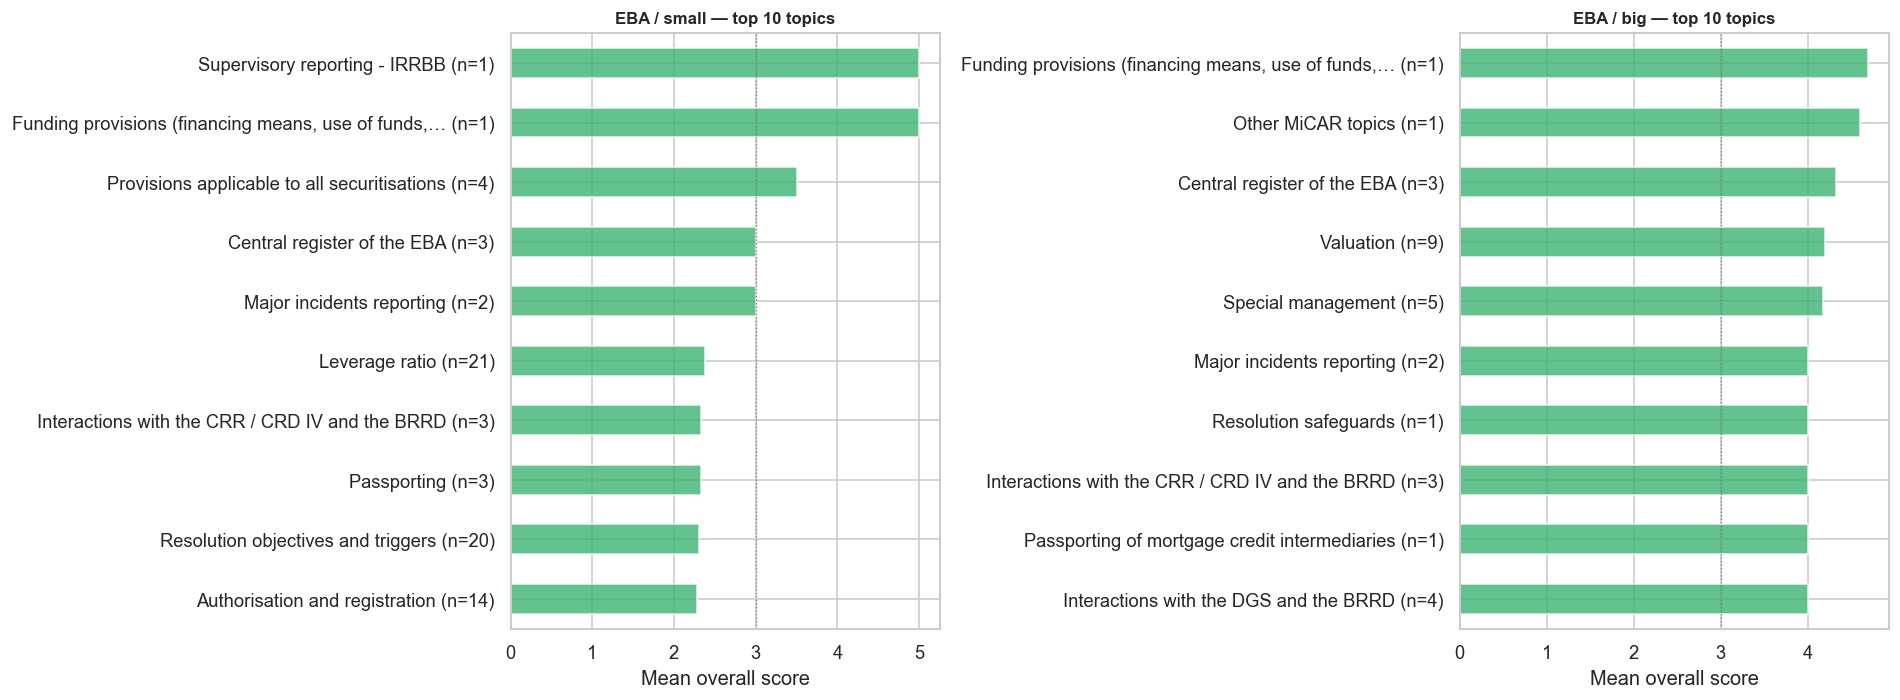

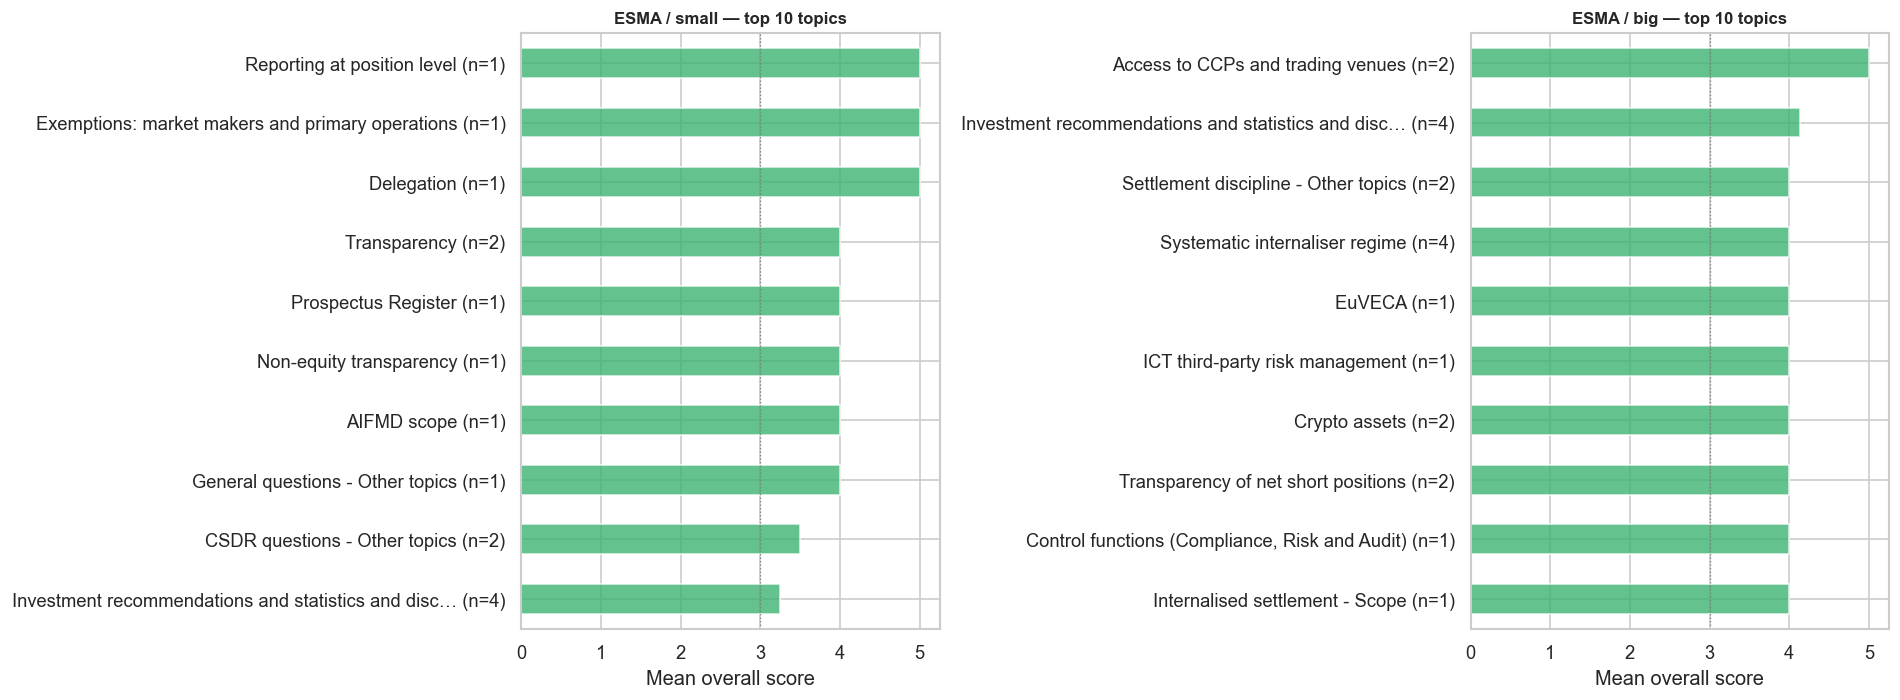

In [19]:
# Top topics by mean overall score (EBA small & big)
def top_topic_plot(df_small, df_big, corpus, top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, (df, tier) in zip(axes, [(df_small, "small"), (df_big, "big")]):
        top = (df.groupby("topic")["overall"]
                 .mean()
                 .dropna()
                 .sort_values(ascending=False)
                 .head(top_n))
        counts = df["topic"].value_counts().reindex(top.index)
        labels = [f"{shorten(t, 50)} (n={counts[t]})" for t in top.index]
        top.index = labels
        top.plot.barh(ax=ax, color="mediumseagreen", alpha=0.8)
        ax.axvline(3, color="grey", linestyle=":", linewidth=0.8)
        ax.set_xlabel("Mean overall score")
        ax.set_title(f"{corpus} / {tier} — top {top_n} topics", fontsize=10, fontweight="bold")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

top_topic_plot(dfs["EBA / small"],  dfs["EBA / big"],  "EBA")
top_topic_plot(dfs["ESMA / small"], dfs["ESMA / big"], "ESMA")

## 6 · Dimension Correlations

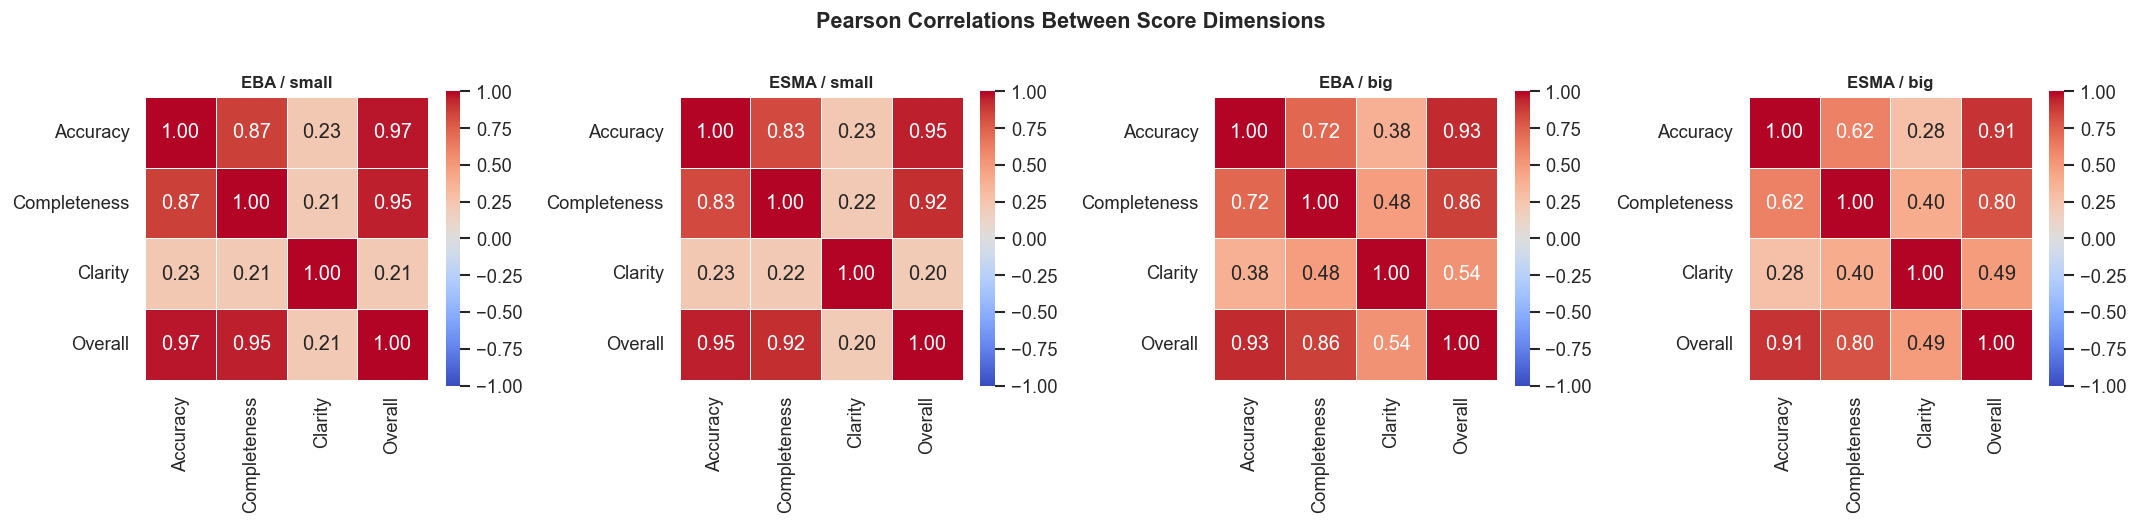

In [20]:
# Pearson correlation heatmaps across the 4 score dimensions
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, df) in zip(axes, dfs.items()):
    corr = df[DIMS].dropna().corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, linewidths=0.5, square=True,
                xticklabels=[d.capitalize() for d in DIMS],
                yticklabels=[d.capitalize() for d in DIMS])
    ax.set_title(name, fontsize=10, fontweight="bold")

plt.suptitle("Pearson Correlations Between Score Dimensions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

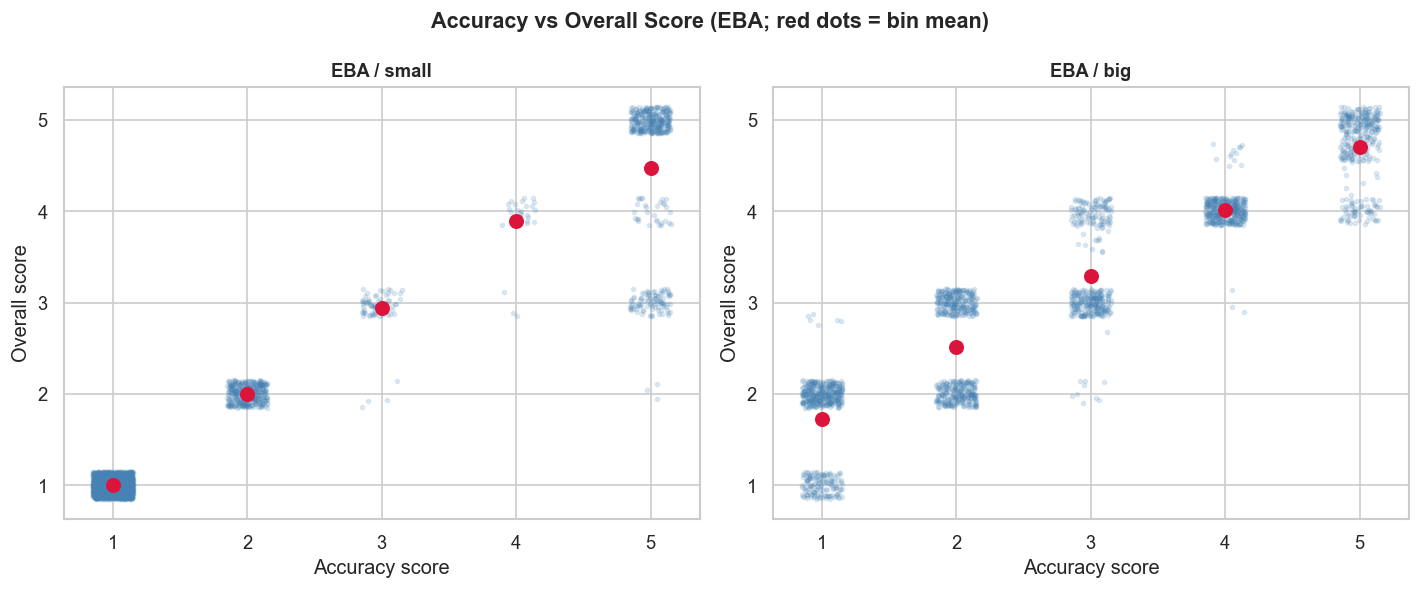

In [21]:
# Scatter: accuracy vs overall (small vs big, EBA)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tier in zip(axes, ["small", "big"]):
    key = f"EBA / {tier}"
    df = dfs[key].dropna(subset=["accuracy", "overall"])
    # jitter to reveal density
    jx = df["accuracy"]  + np.random.uniform(-0.15, 0.15, len(df))
    jy = df["overall"]   + np.random.uniform(-0.15, 0.15, len(df))
    ax.scatter(jx, jy, alpha=0.15, s=6, color="steelblue")
    # overlay mean per integer accuracy bin
    for acc_val in [1, 2, 3, 4, 5]:
        sub = df[df["accuracy"].round() == acc_val]["overall"]
        if len(sub):
            ax.plot(acc_val, sub.mean(), "o", color="crimson", markersize=8, zorder=5)
    ax.set_xlabel("Accuracy score")
    ax.set_ylabel("Overall score")
    ax.set_title(f"EBA / {tier}", fontsize=11, fontweight="bold")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_yticks([1, 2, 3, 4, 5])

plt.suptitle("Accuracy vs Overall Score (EBA; red dots = bin mean)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 · Example Answers at Score Extremes

In [22]:
def show_example(df, label, target_score, n=2):
    subset = df[df["overall"].round() == target_score].dropna(subset=["overall"])
    sample = subset.sample(min(n, len(subset)), random_state=42)
    print(f"\n{'='*80}")
    print(f"  {label}  |  overall ≈ {target_score}  ({len(subset)} matching records)")
    print(f"{'='*80}")
    for _, row in sample.iterrows():
        print(f"\n[ID: {row['id']}]")
        print(f"QUESTION   : {row['question'][:300]}{'...' if len(row['question'])>300 else ''}")
        print(f"GROUND TRUTH: {row['ground_truth'][:300]}{'...' if len(row['ground_truth'])>300 else ''}")
        print(f"CANDIDATE  : {row['candidate_answer'][:300]}{'...' if len(row['candidate_answer'])>300 else ''}")
        print(f"SCORES     : acc={row['accuracy']}  comp={row['completeness']}  clar={row['clarity']}  overall={row['overall']}")
        print(f"REASONING  : {row['reasoning']}")
        print()

# EBA small: best and worst
show_example(dfs["EBA / small"], "EBA / small", target_score=5)
show_example(dfs["EBA / small"], "EBA / small", target_score=1)

# EBA big: best and worst
show_example(dfs["EBA / big"],   "EBA / big",   target_score=5)
show_example(dfs["EBA / big"],   "EBA / big",   target_score=1)


  EBA / small  |  overall ≈ 5  (310 matching records)

[ID: 2025_7454]
QUESTION   : C 02.00 – Row 690/ Col 0020 (Other RWA under S-TREA):
If the firm were back testing any models that identified a shortfall, would this necessarily result in the equivalent Fully Standardised RWA needing to be computed, given that the fully standardised position would be driven by rule-based criteria...
GROUND TRUTH: In template C 02.00 of Implementing technical standard (EU) 2024/3117 (ITS on reporting), there will be no impact on S-TREA (c0020, r0690) for additional RWA due to PMA / model shortfall; as well as competent authority (regulator) driven add ons.
CANDIDATE  : No, the firm would not necessarily need to compute the equivalent Fully Standardised RWA if the shortfall is identified by back-testing a model, as the fully standardised position is already captured in the appropriate rows before Row 690.
SCORES     : acc=5.0  comp=5.0  clar=5.0  overall=5.0
REASONING  : The candidate answer perfectly

## 8 · Missing Score Analysis (Big Models)

=== EBA / big — 536 missing overall scores (20.3%) ===
  Top legal acts with missing scores:
    Regulation (EU) No 575/2013 (CRR)                               400
    Directive 2014/59/EU (BRRD)                                     53
    Directive 2015/2366/EU (PSD2)                                   49
    Directive 2013/36/EU (CRD)                                      18
    Regulation (EU) No 2022/2554 (DORA Reg)                         6
  Top topics with missing scores:
    Supervisory reporting - FINREP (incl. FB&NPE)                   75
    Supervisory reporting - COREP (incl. IP Losses)                 67
    Credit risk                                                     52
    Supervisory reporting - Liquidity (LCR, NSFR, AMM)              42
    Liquidity risk                                                  41

=== ESMA / big — 94 missing overall scores (24.5%) ===
  Top legal acts with missing scores:
    Markets in Financial Instruments Directive II (MiFID II) Dir…   1

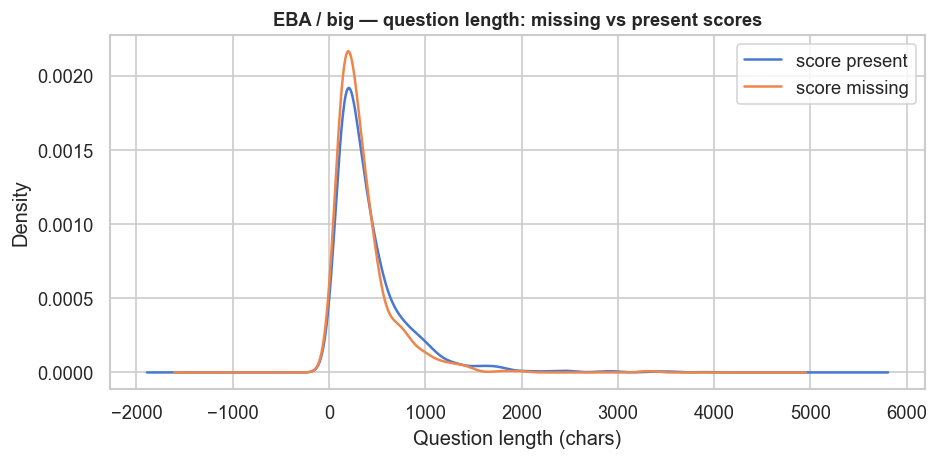

In [23]:
# Big model results have some None scores — examine how they distribute across topics/legal acts
for corpus in ["EBA", "ESMA"]:
    df = dfs[f"{corpus} / big"]
    missing = df[df["overall"].isna()]
    print(f"=== {corpus} / big — {len(missing)} missing overall scores ({len(missing)/len(df)*100:.1f}%) ===")
    if len(missing):
        print("  Top legal acts with missing scores:")
        for la, cnt in missing["legal_act"].value_counts().head(5).items():
            print(f"    {shorten(la, 60):62s}  {cnt}")
        print("  Top topics with missing scores:")
        for t, cnt in missing["topic"].value_counts().head(5).items():
            print(f"    {shorten(t, 60):62s}  {cnt}")
    print()

# Missing vs present: is there a systematic bias in question length?
df_big = dfs["EBA / big"].copy()
df_big["q_len"] = df_big["question"].str.len()
df_big["missing"] = df_big["overall"].isna()

fig, ax = plt.subplots(figsize=(8, 4))
df_big.groupby("missing")["q_len"].plot.kde(ax=ax)
ax.set_xlabel("Question length (chars)")
ax.set_title("EBA / big — question length: missing vs present scores", fontsize=11, fontweight="bold")
ax.legend(["score present", "score missing"])
plt.tight_layout()
plt.show()

## 9 · Inter-rater Agreement: Small vs Big Models

Cohen's weighted kappa and Krippendorff's α treat the two evaluation pipelines (small vs big) as **two raters** scoring the same questions.  
Scores are rounded to integers 1–5 before computing kappa (big-model outputs occasionally contain fractional values).  
Krippendorff's α uses the **interval metric** d²(k,l) = (k−l)², a standard approximation for ordinal data.

Landis–Koch benchmarks for κ: < 0.20 slight · 0.21–0.40 fair · 0.41–0.60 moderate · 0.61–0.80 substantial · > 0.80 almost perfect.  
Krippendorff recommends α ≥ 0.80 for reliable data; α ≥ 0.667 for tentative conclusions.

In [25]:
from sklearn.metrics import cohen_kappa_score

def krippendorff_alpha_interval(y1, y2):
    """Krippendorff's alpha with interval metric d²(k,l)=(k-l)² for two raters.
    
    Uses the efficient closed-form:
      D_o = mean((y1 - y2)^2)
      D_e = [2N·Σv² - 2·(Σv)²] / [N·(N-1)]   where v = concat(y1, y2), N = 2n
    """
    y1, y2 = np.asarray(y1, float), np.asarray(y2, float)
    D_o = np.mean((y1 - y2) ** 2)
    all_v = np.concatenate([y1, y2])
    N = len(all_v)
    D_e = (2 * N * np.sum(all_v ** 2) - 2 * np.sum(all_v) ** 2) / (N * (N - 1))
    return np.nan if D_e == 0 else 1.0 - D_o / D_e


rows = []
for corpus in ["EBA", "ESMA"]:
    df_s = dfs[f"{corpus} / small"]
    df_b = dfs[f"{corpus} / big"]

    merged = (
        df_s[["id"] + DIMS]
        .rename(columns={d: f"{d}_s" for d in DIMS})
        .merge(
            df_b[["id"] + DIMS].rename(columns={d: f"{d}_b" for d in DIMS}),
            on="id",
        )
    )

    for dim in DIMS:
        sub = merged[[f"{dim}_s", f"{dim}_b"]].dropna()
        # Round big-model fractional scores and clip to valid range
        y_s = np.clip(sub[f"{dim}_s"].round(), 1, 5).astype(int).values
        y_b = np.clip(sub[f"{dim}_b"].round(), 1, 5).astype(int).values

        rows.append({
            "corpus":            corpus,
            "dimension":         dim,
            "n_pairs":           len(sub),
            "kappa_linear":      cohen_kappa_score(y_s, y_b, labels=[1,2,3,4,5], weights="linear"),
            "kappa_quadratic":   cohen_kappa_score(y_s, y_b, labels=[1,2,3,4,5], weights="quadratic"),
            "krippendorff_alpha": krippendorff_alpha_interval(y_s, y_b),
        })

agree_df = pd.DataFrame(rows)
agree_df.set_index(["corpus", "dimension"]).round(3)

n_pairs  kappa_linear  kappa_quadratic  \
corpus dimension                                              
EBA    accuracy         2097         0.132            0.170   
       completeness     2097         0.074            0.119   
       clarity          2097         0.055            0.066   
       overall          2097         0.097            0.158   
ESMA   accuracy          289         0.047            0.017   
       completeness      289         0.058            0.072   
       clarity           289         0.062            0.064   
       overall           289         0.037            0.042   

                     krippendorff_alpha  
corpus dimension                         
EBA    accuracy                   0.093  
       completeness              -0.187  
       clarity                    0.016  
       overall                   -0.027  
ESMA   accuracy                  -0.019  
       completeness              -0.230  
       clarity                   -0.035  
       overall                   -0.096

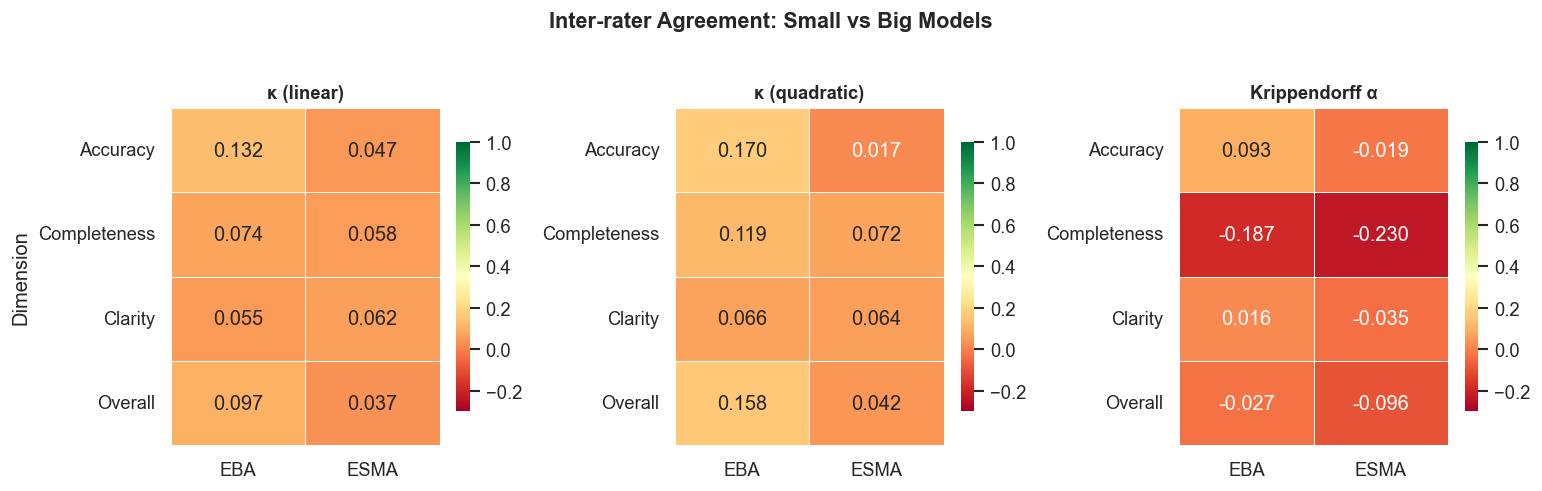

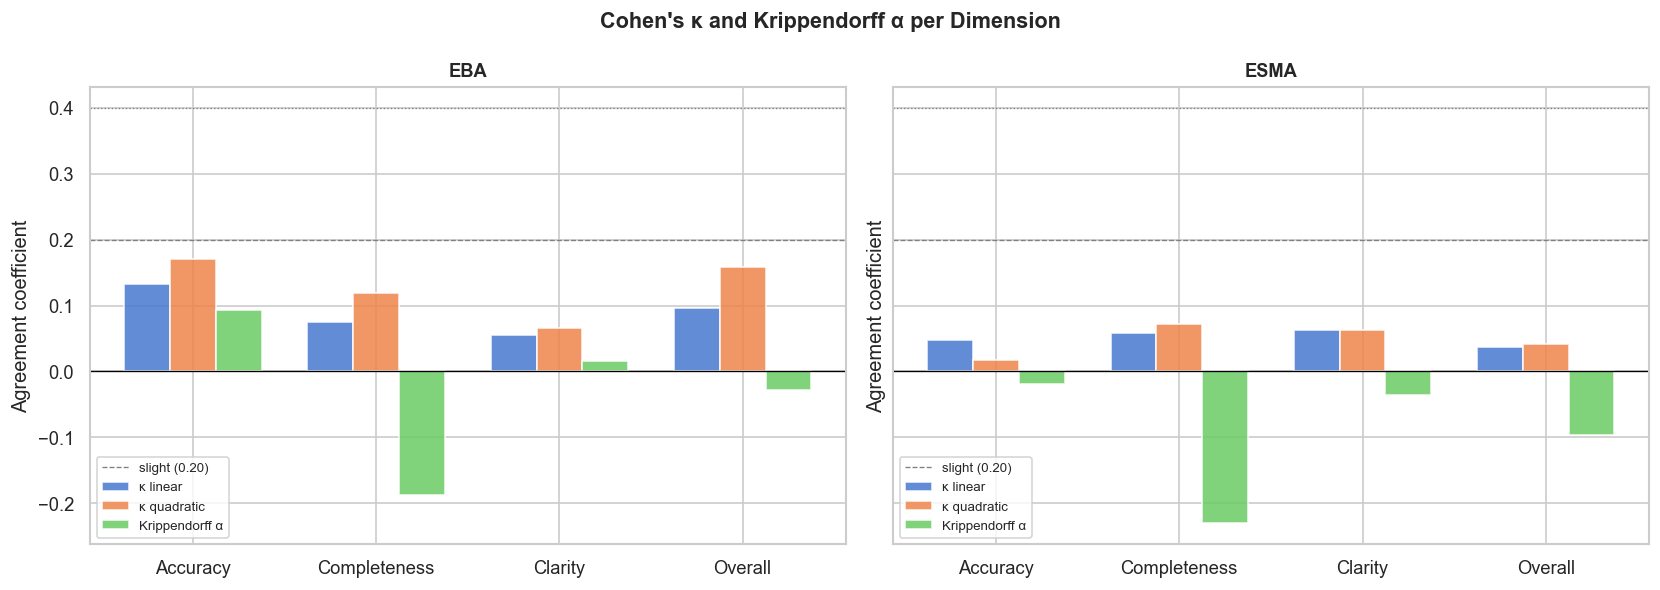

In [26]:
# Heatmap: one panel per metric, rows = dimensions, cols = corpus
metrics = {
    "κ (linear)":    "kappa_linear",
    "κ (quadratic)": "kappa_quadratic",
    "Krippendorff α": "krippendorff_alpha",
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (title, col) in zip(axes, metrics.items()):
    pivot = agree_df.pivot(index="dimension", columns="corpus", values=col)
    pivot = pivot.reindex(DIMS)   # keep consistent dim order
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=-0.3, vmax=1.0, linewidths=0.5, square=False,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Dimension" if ax is axes[0] else "")
    ax.set_yticklabels([d.capitalize() for d in DIMS], rotation=0)

plt.suptitle("Inter-rater Agreement: Small vs Big Models", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Reference lines on a bar chart — all three metrics together per corpus/dim
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

metric_cols  = ["kappa_linear", "kappa_quadratic", "krippendorff_alpha"]
metric_labels = ["κ linear", "κ quadratic", "Krippendorff α"]
x = np.arange(len(DIMS))
width = 0.25

for ax, corpus in zip(axes, ["EBA", "ESMA"]):
    sub = agree_df[agree_df["corpus"] == corpus].set_index("dimension").reindex(DIMS)
    for i, (mcol, mlabel) in enumerate(zip(metric_cols, metric_labels)):
        ax.bar(x + (i - 1) * width, sub[mcol], width, label=mlabel, alpha=0.85)
    ax.axhline(0,    color="black", linewidth=0.8, linestyle="-")
    ax.axhline(0.20, color="grey",  linewidth=0.8, linestyle="--", label="slight (0.20)")
    ax.axhline(0.40, color="grey",  linewidth=0.8, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() for d in DIMS])
    ax.set_ylabel("Agreement coefficient")
    ax.set_title(corpus, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Cohen's κ and Krippendorff α per Dimension", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

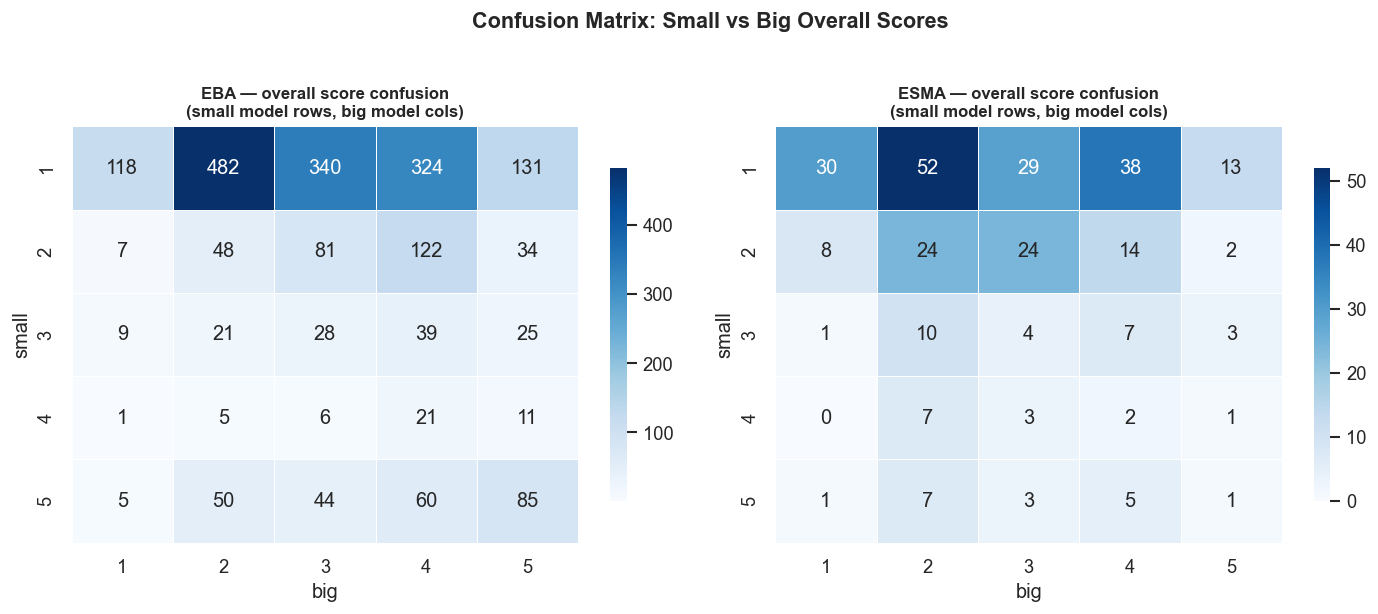

In [27]:
# Confusion matrix for overall score: small (rows) vs big (cols) — EBA only
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, corpus in zip(axes, ["EBA", "ESMA"]):
    df_s = dfs[f"{corpus} / small"]
    df_b = dfs[f"{corpus} / big"]
    merged = (
        df_s[["id", "overall"]].rename(columns={"overall": "small"})
        .merge(df_b[["id", "overall"]].rename(columns={"overall": "big"}), on="id")
        .dropna()
    )
    y_s = np.clip(merged["small"].round(), 1, 5).astype(int)
    y_b = np.clip(merged["big"].round(),   1, 5).astype(int)

    conf = pd.crosstab(y_s, y_b, rownames=["small"], colnames=["big"])
    conf = conf.reindex(index=[1,2,3,4,5], columns=[1,2,3,4,5], fill_value=0)

    sns.heatmap(conf, ax=ax, annot=True, fmt="d", cmap="Blues",
                linewidths=0.3, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{corpus} — overall score confusion\n(small model rows, big model cols)",
                 fontsize=10, fontweight="bold")

plt.suptitle("Confusion Matrix: Small vs Big Overall Scores", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Examples with largest disagreement in overall score (small vs big)
def show_disagreements(corpus, n=5, dim="overall"):
    df_s = dfs[f"{corpus} / small"]
    df_b = dfs[f"{corpus} / big"]

    cols = ["id", "question", "ground_truth", "candidate_answer", "reasoning"] + DIMS
    merged = (
        df_s[[c for c in cols if c in df_s.columns]]
        .rename(columns=lambda c: f"{c}_s" if c != "id" else c)
        .merge(
            df_b[[c for c in cols if c in df_b.columns]]
            .rename(columns=lambda c: f"{c}_b" if c != "id" else c),
            on="id",
        )
        .dropna(subset=[f"{dim}_s", f"{dim}_b"])
    )

    merged["gap"] = (merged[f"{dim}_b"] - merged[f"{dim}_s"]).abs()
    top = merged.nlargest(n, "gap")

    print(f"\n{'='*90}")
    print(f"  {corpus} — top {n} biggest disagreements on [{dim}]  "
          f"(small vs big, rounded scores)")
    print(f"{'='*90}")

    for _, row in top.iterrows():
        s_scores = {d: row[f"{d}_s"] for d in DIMS}
        b_scores = {d: row[f"{d}_b"] for d in DIMS}
        gap = row["gap"]

        print(f"\n[ID: {row['id']}]  gap={gap:.1f}"
              f"  small={s_scores}  big={b_scores}")
        print(f"\nQUESTION:")
        print(f"  {row['question_s'][:400]}{'…' if len(row['question_s']) > 400 else ''}")
        print(f"\nGROUND TRUTH:")
        print(f"  {row['ground_truth_s'][:400]}{'…' if len(row['ground_truth_s']) > 400 else ''}")
        print(f"\nCANDIDATE (small model):")
        print(f"  {row['candidate_answer_s'][:400]}{'…' if len(row['candidate_answer_s']) > 400 else ''}")
        print(f"\nCANDIDATE (big model):")
        print(f"  {row['candidate_answer_b'][:400]}{'…' if len(row['candidate_answer_b']) > 400 else ''}")
        print(f"\nJUDGE REASONING (small): {row['reasoning_s']}")
        print(f"JUDGE REASONING (big):   {row['reasoning_b']}")
        print(f"\n{'-'*90}")

show_disagreements("EBA",  n=5)
show_disagreements("ESMA", n=3)


  EBA — top 5 biggest disagreements on [overall]  (small vs big, rounded scores)

[ID: 2013_638]  gap=4.0  small={'accuracy': 1.0, 'completeness': 1.0, 'clarity': 5.0, 'overall': 1.0}  big={'accuracy': 5.0, 'completeness': 5.0, 'clarity': 5.0, 'overall': 5.0}

QUESTION:
  Article 389 of the CRR states that for Large Exposure Reporting, the exposure should be identical to those in the standardised approach (Part II, Title 2, Chapter II) just without applying risk weights. According to Standard Approach for assets the risk position is defined by the balance sheet value including accrued interest and impairments being deducted. Can you confirm that this is also the de…

GROUND TRUTH:
  For the purposes of the large exposures regime, "exposures" are defined in Article 389 of Regulation (EU) No. 575/2013 (CRR) as any asset or off-balance sheet item referred to in Part Three, Title II, Chapter 2 of the CRR (i.e. Standardised Approach, Article 111 of the CRR et seq.), without applying the ri